<a href="https://colab.research.google.com/github/shweeta1015/CNN-Animal-Classification-Stride-1-vs-Stride-2/blob/main/CNN_Animal_Classification_Stride_1_vs_Stride_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Animal Classification Using CNN

### Classification of Four Animals Using Stride = 1 and Stride = 2

Animals:
1. Cat
2. Deer
3. Dog
4. Frog


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import time

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [ ]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

print("Original training images:", x_train_full.shape)
print("Original testing images :", x_test_full.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1788s 10us/step
Original training images: (50000, 32, 32, 3)
Original testing images : (10000, 32, 32, 3)


In [ ]:
animal_classes = {
    3: "Cat",
    4: "Deer",
    5: "Dog",
    6: "Frog"
}

print(animal_classes)

{3: 'Cat', 4: 'Deer', 5: 'Dog', 6: 'Frog'}


In [ ]:
selected_classes = [3, 4, 5, 6]

# Training data
train_mask = np.isin(
    y_train_full.flatten(),
    selected_classes
)

x_train = x_train_full[train_mask]
y_train = y_train_full[train_mask].flatten()

# Testing data
test_mask = np.isin(
    y_test_full.flatten(),
    selected_classes
)

x_test = x_test_full[test_mask]
y_test = y_test_full[test_mask].flatten()

print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)

Training images: (20000, 32, 32, 3)
Testing images : (4000, 32, 32, 3)


In [ ]:
label_mapping = {
    3: 0,   # Cat
    4: 1,   # Deer
    5: 2,   # Dog
    6: 3    # Frog
}

y_train = np.array([
    label_mapping[label]
    for label in y_train
])

y_test = np.array([
    label_mapping[label]
    for label in y_test
])

class_names = [
    "Cat",
    "Deer",
    "Dog",
    "Frog"
]

print("Classes:", class_names)
print("Training labels:", np.unique(y_train))
print("Testing labels :", np.unique(y_test))

Classes: ['Cat', 'Deer', 'Dog', 'Frog']
Training labels: [0 1 2 3]
Testing labels : [0 1 2 3]


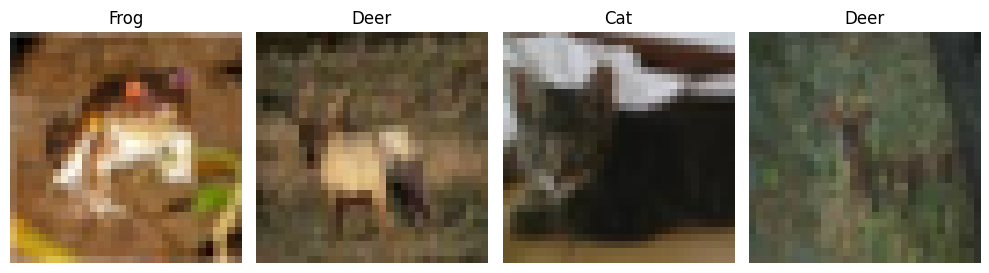

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(4):

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_train[i])

    plt.title(class_names[y_train[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
unique, counts = np.unique(
    y_train,
    return_counts=True
)

for label, count in zip(unique, counts):
    print(
        f"{class_names[label]}: {count} images"
    )

Cat: 5000 images
Deer: 5000 images
Dog: 5000 images
Frog: 5000 images


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
model_stride1 = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    # Convolution with stride = 1
    layers.Conv2D(
        32,
        (3, 3),
        strides=(1, 1),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        strides=(1, 1),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        128,
        (3, 3),
        strides=(1, 1),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        4,
        activation="softmax"
    )
])

model_stride1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,036 (1.36 MB)

 Trainable params: 356,036 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_stride1.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
start_time = time.time()

history_stride1 = model_stride1.fit(

    x_train,
    y_train,

    validation_split=0.1,

    epochs=10,

    batch_size=64,

    verbose=1
)

stride1_time = time.time() - start_time

print(
    f"\nStride = 1 training time: "
    f"{stride1_time:.2f} seconds"
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 47s 156ms/step - accuracy: 0.4689 - loss: 1.1615 - val_accuracy: 0.5815 - val_loss: 0.9647
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 44s 156ms/step - accuracy: 0.5977 - loss: 0.9532 - val_accuracy: 0.5125 - val_loss: 1.1885
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 43s 153ms/step - accuracy: 0.6449 - loss: 0.8655 - val_accuracy: 0.6860 - val_loss: 0.7782
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 43s 153ms/step - accuracy: 0.6861 - loss: 0.7707 - val_accuracy: 0.6995 - val_loss: 0.7344
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 153ms/step - accuracy: 0.7138 - loss: 0.7182 - val_accuracy: 0.7070 - val_loss: 0.7157
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 43s 153ms/step - accuracy: 0.7403 - loss: 0.6524 - val_accuracy: 0.7120 - val_loss: 0.7098
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 43s 153ms/step - accuracy: 0.7647 - loss: 0.6010 - val_accuracy: 0.7340 - val_loss: 0.6592
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 154ms/step - accuracy: 0.7858 - loss: 0

In [ ]:
test_loss_1, test_accuracy_1 = model_stride1.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(
    f"Stride = 1 Test Accuracy: "
    f"{test_accuracy_1:.4f}"
)

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7290 - loss: 0.7007
Stride = 1 Test Accuracy: 0.7290


In [ ]:
y_pred_prob_1 = model_stride1.predict(
    x_test,
    verbose=0
)

y_pred_1 = np.argmax(
    y_pred_prob_1,
    axis=1
)

print("Predictions generated.")

Predictions generated.


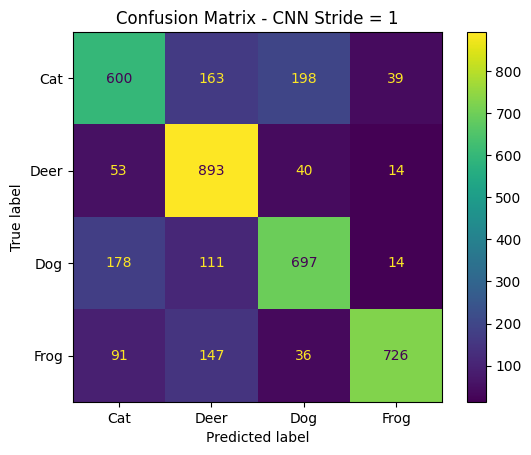

In [ ]:
cm1 = confusion_matrix(
    y_test,
    y_pred_1
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=class_names
)

disp.plot()

plt.title(
    "Confusion Matrix - CNN Stride = 1"
)

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_1,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         Cat       0.65      0.60      0.62      1000
        Deer       0.68      0.89      0.77      1000
         Dog       0.72      0.70      0.71      1000
        Frog       0.92      0.73      0.81      1000

    accuracy                           0.73      4000
   macro avg       0.74      0.73      0.73      4000
weighted avg       0.74      0.73      0.73      4000



In [ ]:
# STEP 18: CNN with Stride = 2

model_stride2 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Convolution Layer 1
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=(2, 2),
        padding="same",
        activation="relu"
    ),

    # Pooling Layer 1
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Layer 2
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        strides=(2, 2),
        padding="same",
        activation="relu"
    ),

    # Pooling Layer 2
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Layer 3
    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        strides=(2, 2),
        padding="same",
        activation="relu"
    ),

    # Pooling Layer 3
    # SAME padding prevents the 1x1 feature map from causing an error
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same"
    ),

    # Flatten
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    # Output Layer
    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
])

model_stride2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 19: Compile CNN with Stride = 2

model_stride2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Stride = 2 CNN compiled successfully.")

Stride = 2 CNN compiled successfully.


In [ ]:
# STEP 20: Train CNN with Stride = 2

start_time_2 = time.time()

history_stride2 = model_stride2.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)

stride2_time = time.time() - start_time_2

print(f"Stride = 2 training time: {stride2_time:.2f} seconds")

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4029 - loss: 1.2426 - val_accuracy: 0.5235 - val_loss: 1.1080
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5293 - loss: 1.0640 - val_accuracy: 0.5585 - val_loss: 0.9999
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5778 - loss: 0.9805 - val_accuracy: 0.5880 - val_loss: 0.9614
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6070 - loss: 0.9205 - val_accuracy: 0.6170 - val_loss: 0.8903
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6228 - loss: 0.8832 - val_accuracy: 0.6070 - val_loss: 0.9267
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6527 - loss: 0.8348 - val_accuracy: 0.6210 - val_loss: 0.8858
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6708 - loss: 0.8008 - val_accuracy: 0.6555 - val_loss: 0.8216
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6884 - loss: 0.7596 - val_acc

In [ ]:
test_loss_2, test_accuracy_2 = model_stride2.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(
    f"Stride = 2 Test Accuracy: "
    f"{test_accuracy_2:.4f}"
)

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6615 - loss: 0.8253
Stride = 2 Test Accuracy: 0.6615


In [ ]:
y_pred_prob_2 = model_stride2.predict(
    x_test,
    verbose=0
)

y_pred_2 = np.argmax(
    y_pred_prob_2,
    axis=1
)

print("Stride = 2 predictions generated.")

Stride = 2 predictions generated.


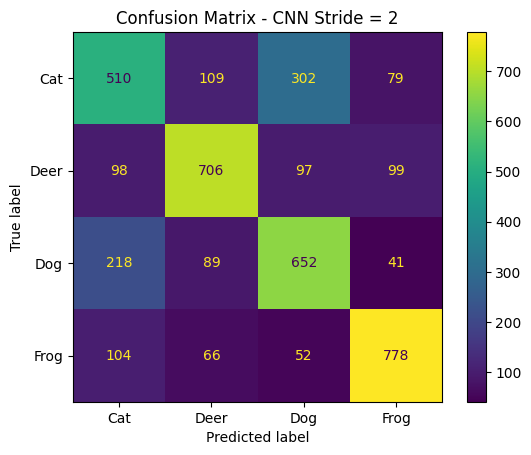

In [ ]:
cm2 = confusion_matrix(
    y_test,
    y_pred_2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=class_names
)

disp.plot()

plt.title(
    "Confusion Matrix - CNN Stride = 2"
)

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_2,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         Cat       0.55      0.51      0.53      1000
        Deer       0.73      0.71      0.72      1000
         Dog       0.59      0.65      0.62      1000
        Frog       0.78      0.78      0.78      1000

    accuracy                           0.66      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.66      0.66      0.66      4000



In [ ]:
print("========================================")
print("     STRIDE COMPARISON")
print("========================================")

print(
    f"Stride = 1 Accuracy : "
    f"{test_accuracy_1:.4f}"
)

print(
    f"Stride = 2 Accuracy : "
    f"{test_accuracy_2:.4f}"
)

print(
    f"Stride = 1 Time     : "
    f"{stride1_time:.2f} seconds"
)

print(
    f"Stride = 2 Time     : "
    f"{stride2_time:.2f} seconds"
)

     STRIDE COMPARISON
Stride = 1 Accuracy : 0.7290
Stride = 2 Accuracy : 0.6615
Stride = 1 Time     : 553.65 seconds
Stride = 2 Time     : 75.32 seconds


In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Parameter": [
        "Stride",
        "Test Accuracy",
        "Training Time"
    ],

    "CNN - Stride 1": [
        "1",
        f"{test_accuracy_1:.4f}",
        f"{stride1_time:.2f} sec"
    ],

    "CNN - Stride 2": [
        "2",
        f"{test_accuracy_2:.4f}",
        f"{stride2_time:.2f} sec"
    ]
})

comparison

,Parameter,CNN - Stride 1,CNN - Stride 2
0,Stride,1,2
1,Test Accuracy,0.7290,0.6615
2,Training Time,553.65 sec,75.32 sec


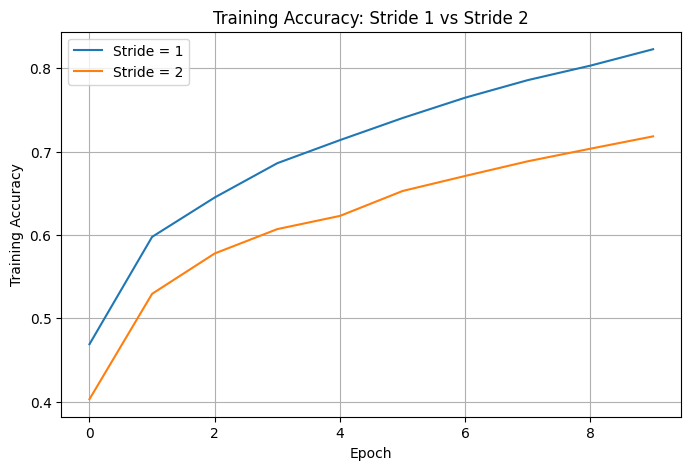

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_stride1.history["accuracy"],
    label="Stride = 1"
)

plt.plot(
    history_stride2.history["accuracy"],
    label="Stride = 2"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")

plt.title(
    "Training Accuracy: Stride 1 vs Stride 2"
)

plt.legend()
plt.grid()

plt.show()

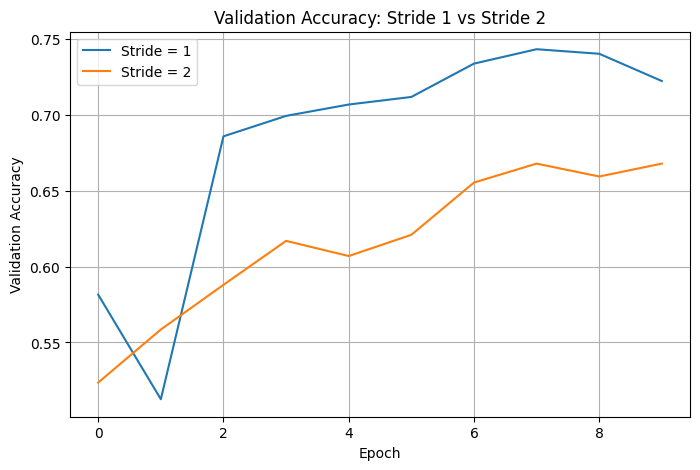

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_stride1.history["val_accuracy"],
    label="Stride = 1"
)

plt.plot(
    history_stride2.history["val_accuracy"],
    label="Stride = 2"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title(
    "Validation Accuracy: Stride 1 vs Stride 2"
)

plt.legend()
plt.grid()

plt.show()